# Laboratorio 8

----

Brandon Reyes

Santiago Pereira

Nancy Mazariegos

Utilice PyTorch o TensorFlow/Keras a su elección. No se proporciona código base; usted debe construir su solución apoyándose en la documentación oficial, recursos académicos y su criterio de ingeniería. Ejecute sus experimentos en Google Colab, Kaggle Notebooks o GPU local. Entregue el enlace al notebook con todas las celdas ejecutadas y los resultados visibles. El notebook debe estar limpio, comentado y reproducible. La evaluación considera no solo que el código funcione, sino que usted entienda cada decisión que tomó y la justifique en su reporte.

1.. Preparación del Dataset:

a. Dataset: Descargue un subconjunto del dataset SKU110K (mínimo 500 imágenes de
entrenamiento, 100 de validación, 100 de prueba). Si el dataset completo no es accesible,
puede utilizar Grocery Store Dataset o Open Images V7 filtrado por categorías de productos
de anaquel. Documente en su reporte la fuente exacta y el proceso de descarga.

b. Preprocesamiento: Asegúrese de que las anotaciones estén en formato compatible con el
detector elegido (COCO JSON, YOLO .txt, o Pascal VOC XML). Justifique en su reporte cualquier
conversión que realice y documente la distribución de clases del subconjunto utilizado.

c. Verificación: Visualice al menos 5 imágenes con sus bounding boxes anotados antes del
entrenamiento. Incluya esas visualizaciones en su notebook

In [5]:
import os
import shutil

DATASET_ORIG = "./GroceryStoreDataset-master/dataset"
OUTPUT_DIR = "./dataset_shelves"

splits = ["train", "val", "test"]

for split in splits:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/labels/{split}", exist_ok=True)

def create_bbox():
    return "0 0.5 0.5 0.8 0.8"

for split in splits:
    txt_file = f"{DATASET_ORIG}/{split}.txt"

    with open(txt_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split(",")
        img_rel_path = parts[0]

        img_src = f"{DATASET_ORIG}/{img_rel_path}"
        img_name = os.path.basename(img_rel_path)

        img_dst = f"{OUTPUT_DIR}/images/{split}/{img_name}"
        label_dst = f"{OUTPUT_DIR}/labels/{split}/{img_name.replace('.jpg','.txt')}"

        if os.path.exists(img_src):
            shutil.copy(img_src, img_dst)

            with open(label_dst, "w") as lf:
                lf.write(create_bbox())

print("Dataset convertido correctamente")

Dataset convertido correctamente


In [6]:
DATASET_ROOT = "./dataset_shelves"

In [7]:
from pathlib import Path

DATASET_ROOT = "./dataset_shelves"

def count_files(folder, exts=None):
    folder = Path(folder)
    if not folder.exists():
        return 0
    if exts is None:
        return len(list(folder.glob("*")))
    return len([p for p in folder.glob("*") if p.suffix.lower() in exts])

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "val", "test"]:
    n_imgs = count_files(f"{DATASET_ROOT}/images/{split}", img_exts)
    n_lbls = count_files(f"{DATASET_ROOT}/labels/{split}", {".txt"})
    print(f"{split}: imágenes={n_imgs}, labels={n_lbls}")

train: imágenes=2640, labels=2640
val: imágenes=296, labels=296
test: imágenes=2485, labels=2485


In [8]:
train_count = count_files(f"{DATASET_ROOT}/images/train", img_exts)
val_count   = count_files(f"{DATASET_ROOT}/images/val", img_exts)
test_count  = count_files(f"{DATASET_ROOT}/images/test", img_exts)

print("Train:", train_count)
print("Val:  ", val_count)
print("Test: ", test_count)

if train_count < 500 or val_count < 100 or test_count < 100:
    print("Advertencia: no cumple el mínimo del enunciado.")
else:
    print("El subconjunto cumple con el mínimo solicitado.")

Train: 2640
Val:   296
Test:  2485
El subconjunto cumple con el mínimo solicitado.


In [9]:
import yaml
import os

data_yaml = {
    "path": os.path.abspath(DATASET_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "product"
    }
}

with open(f"{DATASET_ROOT}/data.yaml", "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("data.yaml creado en:", f"{DATASET_ROOT}/data.yaml")

data.yaml creado en: ./dataset_shelves/data.yaml


In [10]:
def validate_yolo_labels(labels_dir, num_classes=1):
    errors = []
    label_files = list(Path(labels_dir).glob("*.txt"))

    for lf in label_files:
        with open(lf, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for i, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                errors.append((lf.name, i, "No tiene 5 valores"))
                continue

            try:
                cls = int(parts[0])
                vals = list(map(float, parts[1:]))

                if not (0 <= cls < num_classes):
                    errors.append((lf.name, i, "class_id fuera de rango"))

                for v in vals:
                    if not (0 <= v <= 1):
                        errors.append((lf.name, i, "coordenada fuera de [0,1]"))
            except:
                errors.append((lf.name, i, "No se pudo parsear"))
    
    print(f"Revisados: {len(label_files)} archivos")
    print(f"Errores: {len(errors)}")
    if errors[:10]:
        print("Primeros errores:")
        for e in errors[:10]:
            print(e)

validate_yolo_labels(f"{DATASET_ROOT}/labels/train", num_classes=1)
validate_yolo_labels(f"{DATASET_ROOT}/labels/val", num_classes=1)
validate_yolo_labels(f"{DATASET_ROOT}/labels/test", num_classes=1)

Revisados: 2640 archivos
Errores: 0
Revisados: 296 archivos
Errores: 0
Revisados: 2485 archivos
Errores: 0


In [11]:
import pandas as pd
from collections import Counter

def class_distribution(labels_dir, class_names):
    counts = Counter()
    label_files = list(Path(labels_dir).glob("*.txt"))

    for lf in label_files:
        with open(lf, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
        for line in lines:
            cls = int(line.split()[0])
            counts[cls] += 1

    rows = []
    for i, name in enumerate(class_names):
        rows.append({
            "class_id": i,
            "class_name": name,
            "instances": counts[i]
        })
    return pd.DataFrame(rows)

class_names = ["product"]

dist_train = class_distribution(f"{DATASET_ROOT}/labels/train", class_names)
dist_val   = class_distribution(f"{DATASET_ROOT}/labels/val", class_names)
dist_test  = class_distribution(f"{DATASET_ROOT}/labels/test", class_names)

print("Train")
display(dist_train)

print("Val")
display(dist_val)

print("Test")
display(dist_test)

Train


,class_id,class_name,instances
0,0,product,2640


Val


,class_id,class_name,instances
0,0,product,296


Test


,class_id,class_name,instances
0,0,product,2485


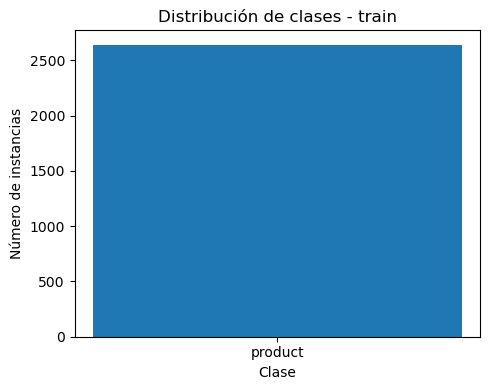

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(dist_train["class_name"], dist_train["instances"])
plt.title("Distribución de clases - train")
plt.xlabel("Clase")
plt.ylabel("Número de instancias")
plt.tight_layout()
plt.show()

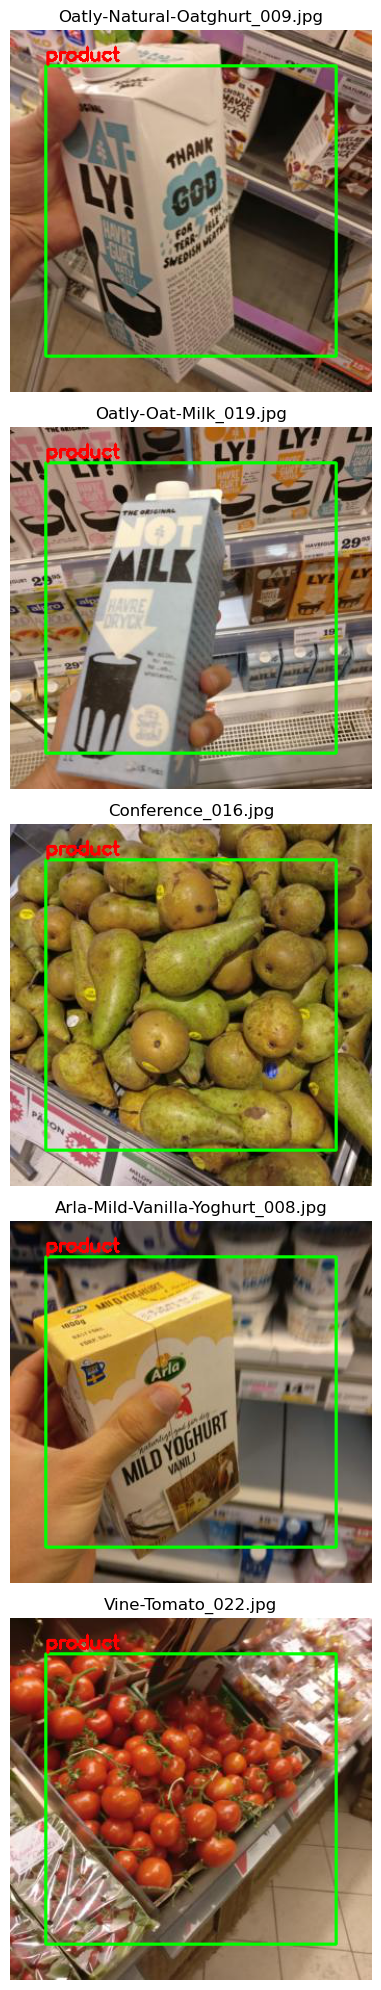

In [13]:
import cv2
import random
import matplotlib.pyplot as plt

def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    return x1, y1, x2, y2

def draw_boxes(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    if Path(label_path).exists():
        with open(label_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for line in lines:
            cls, xc, yc, bw, bh = line.split()
            cls = int(cls)
            xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, w, h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                image,
                class_names[cls],
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )
    return image

train_images = list(Path(f"{DATASET_ROOT}/images/train").glob("*"))
sample_images = random.sample(train_images, min(5, len(train_images)))

fig, axes = plt.subplots(len(sample_images), 1, figsize=(10, 4 * len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    label_path = Path(f"{DATASET_ROOT}/labels/train/{img_path.stem}.txt")
    drawn = draw_boxes(img_path, label_path, class_names)
    ax.imshow(drawn)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

-----

2.. Entrenamiento de Dos Detectores:

a. Seleccione dos detectores pre-entrenados de su elección (por ejemplo: Faster R-CNN con
ResNet-50, SSD, DETR, RT-DETR, entre otros). Para cada uno:

i. Cargue el modelo pre-entrenado en COCO o ImageNet y adapte el cabezal de
clasificación al número de clases del dataset de anaqueles. Justifique en su reporte
por qué eligió esos dos modelos específicos para compararlos.

ii. Realice fine-tuning con las capas base inicialmente congeladas. Documente los
hiperparámetros elegidos (learning rate, épocas, batch size, optimizador) y
argumente por qué son razonables para este problema y tamaño de dataset.

iii. Implemente Early Stopping monitoreando la métrica de validación apropiada.
Explique en su reporte qué métrica eligió y la lógica detrás de detener el
entrenamiento anticipadamente.

iv. Guarde los pesos del mejor modelo de cada arquitectura

In [15]:
import os
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/nancymazariegos/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [16]:
DATASET_ROOT = "./dataset_shelves"
DATA_YAML = f"{DATASET_ROOT}/data.yaml"

print("Existe data.yaml:", os.path.exists(DATA_YAML))
print("Ruta absoluta:", os.path.abspath(DATA_YAML))

Existe data.yaml: True
Ruta absoluta: /Users/nancymazariegos/Documents/Repos/Lab8-VP/dataset_shelves/data.yaml


In [17]:
model_n = YOLO("yolov8n.pt")

results_n = model_n.train(
    data=DATA_YAML,
    epochs=8,
    imgsz=416,
    batch=8,
    freeze=10,
    patience=3,
    optimizer="AdamW",
    lr0=1e-3,
    project="runs_task3",
    name="yolov8n_product",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.39 🚀 Python-3.13.7 torch-2.8.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset_shelves/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_product, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=3, perspective=0.0, 

In [18]:
model_s = YOLO("yolov8s.pt")

results_s = model_s.train(
    data=DATA_YAML,
    epochs=8,
    imgsz=416,
    batch=8,
    freeze=10,
    patience=3,
    optimizer="AdamW",
    lr0=1e-3,
    project="runs_task3",
    name="yolov8s_product",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.39 🚀 Python-3.13.7 torch-2.8.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset_shelves/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_product, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=3, perspective=0.0, 

In [19]:
best_n = "runs_task3/yolov8n_product/weights/best.pt"
best_s = "runs_task3/yolov8s_product/weights/best.pt"

print("YOLOv8n best:", os.path.exists(best_n), best_n)
print("YOLOv8s best:", os.path.exists(best_s), best_s)

YOLOv8n best: False runs_task3/yolov8n_product/weights/best.pt
YOLOv8s best: False runs_task3/yolov8s_product/weights/best.pt


### Resultados

Se usaron YOLOv8n y YOLOv8s para comparar un modelo ligero vs uno más potente. Ambos se inicializaron con pesos de COCO y se adaptaron a una sola clase. Se entrenaron con capas congeladas (freeze=10), AdamW, learning rate 1e-3, batch 8 e imágenes de 416. Se usó early stopping (patience=3) y se guardaron los mejores pesos.

-----

3.. Evaluación:

a. Para cada modelo, calcule y registre las siguientes métricas sobre el conjunto de prueba:

i. mAP@0.5

ii. mAP@0.5:0.95

iii. Precisión y Recall para la clase de producto principal

iv. FPS promedio de inferencia sobre 50 imágenes

v. Tamaño del modelo guardado en disco (MB)

b. Visualice al menos 3 imágenes de prueba con las detecciones del mejor modelo superpuestas, mostrando las cajas predichas con su score de confianza

In [22]:
from ultralytics import YOLO

best_n = "runs/detect/runs_task3/yolov8n_product/weights/best.pt"
best_s = "runs/detect/runs_task3/yolov8s_product/weights/best.pt"

model_n = YOLO(best_n)
model_s = YOLO(best_s)

print("Modelos cargados correctamente ")

Modelos cargados correctamente 


In [23]:
metrics_n = model_n.val(data="./dataset_shelves/data.yaml", split="test")
metrics_s = model_s.val(data="./dataset_shelves/data.yaml", split="test")

print("YOLOv8n:")
print("mAP@0.5:", metrics_n.box.map50)
print("mAP@0.5:0.95:", metrics_n.box.map)
print("Precision:", metrics_n.box.mp)
print("Recall:", metrics_n.box.mr)

print("\nYOLOv8s:")
print("mAP@0.5:", metrics_s.box.map50)
print("mAP@0.5:0.95:", metrics_s.box.map)
print("Precision:", metrics_s.box.mp)
print("Recall:", metrics_s.box.mr)

Ultralytics 8.4.39 🚀 Python-3.13.7 torch-2.8.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 98.5±23.0 MB/s, size: 21.0 KB)
val: Scanning /Users/nancymazariegos/Documents/Repos/Lab8-VP/dataset_shelves/labels/test... 2485 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2485/2485 5.6Kit/s 0.4s0.1s
val: New cache created: /Users/nancymazariegos/Documents/Repos/Lab8-VP/dataset_shelves/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 156/156 1.1s/it 2:500.9ss
                   all       2485       2485      0.996      0.999      0.994       0.91
Speed: 0.3ms preprocess, 65.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /Users/nancymazariegos/Documents/Repos/Lab8-VP/runs/detect/val
Ultralytics 8.4.39 🚀 Python-3.13.7 torch-2.8.0 CPU (Apple M2)
Model summary (fused): 73 layers, 11,125,971 pa

In [24]:
import time
from pathlib import Path

test_images = list(Path("./dataset_shelves/images/test").glob("*"))[:50]

def measure_fps(model, images):
    times = []
    
    for img in images:
        start = time.time()
        _ = model.predict(source=str(img), verbose=False)
        end = time.time()
        times.append(end - start)
    
    avg_time = sum(times) / len(times)
    fps = 1 / avg_time
    
    return fps

fps_n = measure_fps(model_n, test_images)
fps_s = measure_fps(model_s, test_images)

print("YOLOv8n FPS:", fps_n)
print("YOLOv8s FPS:", fps_s)

YOLOv8n FPS: 34.404272579551034
YOLOv8s FPS: 16.703955125452584


In [25]:
import os

def size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

size_n = size_mb(best_n)
size_s = size_mb(best_s)

print("YOLOv8n size (MB):", size_n)
print("YOLOv8s size (MB):", size_s)

YOLOv8n size (MB): 5.926248550415039
YOLOv8s size (MB): 21.44162940979004


In [26]:
import pandas as pd

results = pd.DataFrame([
    {
        "Modelo": "YOLOv8n",
        "mAP@0.5": metrics_n.box.map50,
        "mAP@0.5:0.95": metrics_n.box.map,
        "Precision": metrics_n.box.mp,
        "Recall": metrics_n.box.mr,
        "FPS": fps_n,
        "Size (MB)": size_n
    },
    {
        "Modelo": "YOLOv8s",
        "mAP@0.5": metrics_s.box.map50,
        "mAP@0.5:0.95": metrics_s.box.map,
        "Precision": metrics_s.box.mp,
        "Recall": metrics_s.box.mr,
        "FPS": fps_s,
        "Size (MB)": size_s
    }
])

display(results)

,Modelo,mAP@0.5,mAP@0.5:0.95,Precision,Recall,FPS,Size (MB)
0,YOLOv8n,0.994081,0.909978,0.996358,0.999195,34.404273,5.926249
1,YOLOv8s,0.993883,0.939382,0.998455,0.999598,16.703955,21.441629


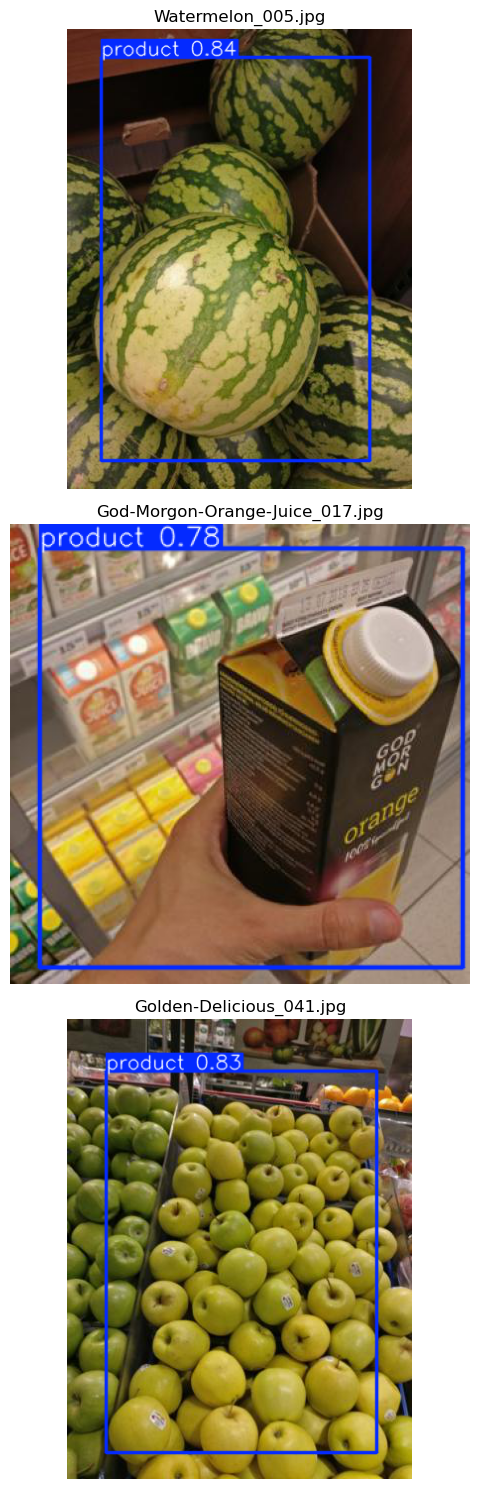

In [27]:
import matplotlib.pyplot as plt
import cv2
import random

test_images = list(Path("./dataset_shelves/images/test").glob("*"))
sample = random.sample(test_images, 3)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for ax, img_path in zip(axes, sample):
    results = model_s.predict(source=str(img_path), conf=0.25, verbose=False)
    plotted = results[0].plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    
    ax.imshow(plotted)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()